# FER-2013: CNN Stabilised (Some additional stabilisations have been made to the model)
This notebook builds an stabilised ANN and creates a shared train/val/test split for fair comparison with a CNN.

## 1. Imports and Configuration
This section imports required libraries and sets global constants for reproducibility and fairness.

In [1]:
# Core utilities
import pathlib
import random

# Numerical work
import numpy as np

# Deep learning framework
import tensorflow as tf

# Plotting
import matplotlib.pyplot as plt

# Splitting + metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# Reproducibility / Fairness
# -----------------------------
# Fix seeds so that the split and training are repeatable
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Paths / Data Settings
# -----------------------------
# Base FER directory that already contains train/ and test/
DATA_DIR = pathlib.Path("./data/fer-2013")

# Training and test folder locations
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

# File we save so BOTH notebooks use identical arrays
SPLITS_PATH = pathlib.Path("./fer-2013_splits.npz")

# FER-2013 images are 48x48 grayscale
IMG_SIZE = (48, 48)

# Training hyperparameters (kept identical for ANN and CNN)
BATCH_SIZE = 64
EPOCHS = 40
LEARNING_RATE = 1e-3

## 2. Load Dataset from Directory
This section loads all FER-2013 training images from the train/ directory into memory.

In [2]:
# Ensure the train folder exists before loading
if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR.resolve()}")

# Load ALL training images using folder labels
# batch_size=None means we get an unbatched dataset so we can split ourselves
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",        # infer labels from subfolder names
    label_mode="int",         # labels as integer indices
    color_mode="grayscale",   # FER-2013 is grayscale
    image_size=IMG_SIZE,      # force 48x48
    batch_size=None,          # keep unbatched for splitting
    shuffle=True,
    seed=SEED
)

# Store class names in consistent order
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Convert tf.data dataset into NumPy arrays
X_train_all, y_train_all = [], []
for x, y in train_ds:
    X_train_all.append(x.numpy())   # image
    y_train_all.append(y.numpy())   # label

# Stack into final tensors
X_train_all = np.stack(X_train_all)          # shape: (N, 48, 48, 1)
y_train_all = np.array(y_train_all).astype(int)

print("Train-all:", X_train_all.shape, y_train_all.shape)

Found 28709 files belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train-all: (28709, 48, 48, 1) (28709,)


## 3. Create and Save Shared Train/Val Split + Load Test
This section creates a stratified train/val split from train/ and loads test/ untouched.

In [3]:
# Only create splits if we haven't already saved them
if SPLITS_PATH.exists():
    print("Split file already exists. Skipping creation.")
else:
    # -----------------------------
    # 1) Split TRAIN into train/val
    # -----------------------------
    # We split ONLY the official training set to create a validation set for early stopping
    # Stratify so each emotion keeps its proportion in both sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.20,           # 80% train / 20% validation
        random_state=SEED,
        stratify=y_train_all
    )

    # -----------------------------
    # 2) Load TEST set untouched
    # -----------------------------
    if not TEST_DIR.exists():
        raise FileNotFoundError(f"TEST_DIR not found: {TEST_DIR.resolve()}")

    # shuffle=False because test should be stable and not mixed
    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=None,
        shuffle=False
    )

    # Convert test dataset into NumPy arrays
    X_test, y_test = [], []
    for x, y in test_ds:
        X_test.append(x.numpy())
        y_test.append(y.numpy())

    X_test = np.stack(X_test)
    y_test = np.array(y_test).astype(int)

    # -----------------------------
    # 3) Normalise pixel intensities
    # -----------------------------
    # Convert to float32 and scale [0,255] -> [0,1]
    X_train = X_train.astype("float32") / 255.0
    X_val   = X_val.astype("float32") / 255.0
    X_test  = X_test.astype("float32") / 255.0

    # -----------------------------
    # 4) Save shared split file
    # -----------------------------
    # This guarantees ANN and CNN train on EXACTLY the same arrays
    np.savez(
        SPLITS_PATH,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val,
        X_test=X_test, y_test=y_test,
        class_names=np.array(class_names)
    )

    print("Saved splits to:", SPLITS_PATH.resolve())

Split file already exists. Skipping creation.


## 4. Load Shared Splits
This section loads the saved splits to guarantee fairness across models.

In [4]:
# Load shared arrays saved in Cell 7
splits = np.load(SPLITS_PATH, allow_pickle=True)

# Unpack splits
X_train, y_train = splits["X_train"], splits["y_train"]
X_val, y_val     = splits["X_val"], splits["y_val"]
X_test, y_test   = splits["X_test"], splits["y_test"]

# Recover class ordering used by folder loader
class_names = splits["class_names"].tolist()
num_classes = len(class_names)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (22967, 48, 48, 1)
Val:   (5742, 48, 48, 1)
Test:  (7178, 48, 48, 1)


## 5. Compute Class Weights (Stabilised)
This section creates balanced class weights to reduce the impact of FER-2013 class imbalance.

In [5]:
# FER-2013 is imbalanced (e.g., "disgust" is rare)
# This builds weights so rare classes contribute more to loss
cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Keras expects a dict {class_index: weight}
class_weights = dict(enumerate(cw))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0265957446808511), 1: np.float64(9.401146131805158), 2: np.float64(1.0012206286237413), 3: np.float64(0.5684338184338185), 4: np.float64(0.8260322255790534), 5: np.float64(0.849120082815735), 6: np.float64(1.2932597556168703)}


## 6. Flatten Images for Stabilised ANN
This section reshapes each image into a vector suitable for a fully connected network.

In [6]:
# ANN baseline uses fully-connected layers, so inputs must be 1D
# 48x48 = 2304 features per image
X_train_f = X_train.reshape(len(X_train), -1)
X_val_f   = X_val.reshape(len(X_val), -1)
X_test_f  = X_test.reshape(len(X_test), -1)

# --- Training-only feature normalisation ---
# Even though pixels are already scaled to [0,1], a Normalization layer can still help
# by standardising features (mean/std) based on TRAIN data only.
# IMPORTANT: never adapt on val/test (avoids leakage).
ann_norm = tf.keras.layers.Normalization()
ann_norm.adapt(X_train_f)


print("Flattened train shape:", X_train_f.shape)

Flattened train shape: (22967, 2304)


## 7. Build and Compile Stabilised ANN
This section defines a simple ANN baseline aligned with taught content.

In [11]:
# --- Stabilised ANN baseline ---
# Still a fully-connected network (not a CNN).
# Changes are aimed at training stability and avoiding majority-class collapse:
# - Normalization layer (adapted on train only)
# - Batch Normalization after Dense layers
# - Slightly reduced dropout (0.30 instead of 0.40)

def build_ann(input_dim, num_classes, norm_layer):
    """
    Builds a stabilised ANN for FER-2013.
    This model still uses flattened pixels, so it lacks CNN spatial inductive bias.
    """
    # Input is a flattened 48x48 image => 2304 features
    inputs = tf.keras.layers.Input(shape=(input_dim,))

    # Apply learned standardisation (train-only adapted)
    x = norm_layer(inputs)

    # Dense block 1
    x = tf.keras.layers.Dense(512)(x)
    x = tf.keras.layers.BatchNormalization()(x)   # helps stabilise learning dynamics
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.30)(x)          # reduce dropout to avoid underfitting/collapse

    # Dense block 2
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    # Output layer for multi-class classification
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    return tf.keras.Model(inputs, outputs, name="ANN_Stabilised")

# Build the ANN using the flattened input dimension
ann = build_ann(input_dim=X_train_f.shape[1], num_classes=num_classes, norm_layer=ann_norm)

# Compile with the same LR / optimiser family as CNN to keep comparison fair
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann.summary()


Model: "ANN_Stabilised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 2304)           │         4,609 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,968 (5.04 MB)

 Trainable params: 1,314,823 (5.02 MB)

 Non-trainable params: 6,145 (24.01 KB)

## 8. Train The Stabilised ANN
This section trains the ANN using early stopping and class weights for stability.

In [8]:
# --- Callbacks ---
# ReduceLROnPlateau lowers the learning rate if validation loss stops improving,
# which can help the ANN escape poor plateaus and improve generalisation.
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )
]


# Train the ANN and store history so we can plot/save learning curves
history = ann.fit(
    X_train_f, y_train,
    validation_data=(X_val_f, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2324 - loss: 1.9952 - val_accuracy: 0.3096 - val_loss: 1.7601 - learning_rate: 0.0010
Epoch 2/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2865 - loss: 1.7969 - val_accuracy: 0.3429 - val_loss: 1.6832 - learning_rate: 0.0010
Epoch 3/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3180 - loss: 1.7085 - val_accuracy: 0.3347 - val_loss: 1.6532 - learning_rate: 0.0010
Epoch 4/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3342 - loss: 1.6498 - val_accuracy: 0.3589 - val_loss: 1.6260 - learning_rate: 0.0010
Epoch 5/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3492 - loss: 1.5962 - val_accuracy: 0.3668 - val_loss: 1.5991 - learning_rate: 0.0010
Epoch 6/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3685 - loss: 1.5408 - val_accuracy: 0.3701 - val_loss: 1.5945 - learning_rate: 0.0010
Epoch 7/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3773 - loss: 1.5018 - 

## 8. Plot & Save Training Curves
This cell generates the learning curves and saves them as PDFs

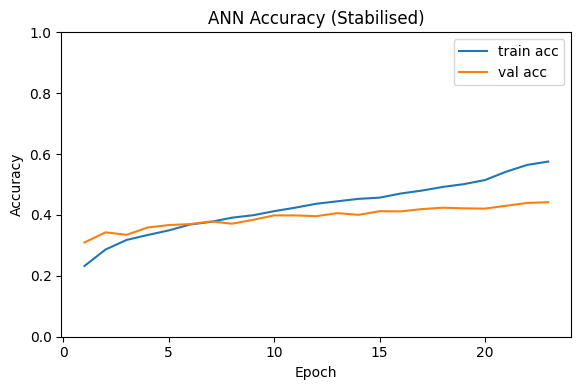

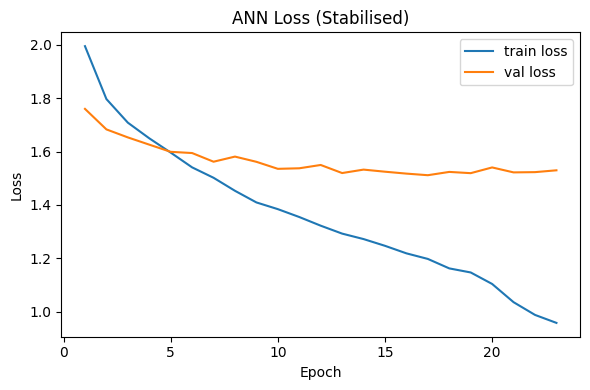

Saved PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\ann\ann_stabilised_accuracy.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\plots\ann\ann_stabilised_loss.pdf


In [9]:
import pathlib
import matplotlib.pyplot as plt

OUT_DIR = pathlib.Path("results/plots/ann/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "ANN"
FILE_PREFIX = "ann_stabilised"

# Work out how many epochs actually ran (EarlyStopping may stop early)
epochs_ran = range(1, len(history.history.get("loss", [])) + 1)

# -------- Accuracy plot --------
plt.figure(figsize=(6, 4))

# Pull accuracy arrays safely (in case keys ever differ)
train_acc = history.history.get("accuracy", None)
val_acc = history.history.get("val_accuracy", None)

if train_acc is not None:
    plt.plot(epochs_ran, train_acc, label="train acc")
if val_acc is not None:
    plt.plot(epochs_ran, val_acc, label="val acc")

plt.title(f"{TITLE_PREFIX} Accuracy (Stabilised)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.ylim(0, 1)

# Save BEFORE show (so the saved PDF matches what you see)
acc_pdf_path = OUT_DIR / f"{FILE_PREFIX}_accuracy.pdf"
plt.savefig(acc_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

# -------- Loss plot --------
plt.figure(figsize=(6, 4))

train_loss = history.history.get("loss", None)
val_loss = history.history.get("val_loss", None)

if train_loss is not None:
    plt.plot(epochs_ran, train_loss, label="train loss")
if val_loss is not None:
    plt.plot(epochs_ran, val_loss, label="val loss")

plt.title(f"{TITLE_PREFIX} Loss (Stabilised)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_pdf_path = OUT_DIR / f"{FILE_PREFIX}_loss.pdf"
plt.savefig(loss_pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved PDFs to:")
print(" -", acc_pdf_path.resolve())
print(" -", loss_pdf_path.resolve())


## 10. Evaluate Stabilised ANN & Show Confusion Matrices
This section reports test performance and produces two confusion matrices for later comparison.

ANN Test Accuracy: 0.4292

Classification Report (ANN Stabilised):
              precision    recall  f1-score   support

       angry       0.33      0.26      0.29       958
     disgust       0.29      0.41      0.34       111
        fear       0.31      0.27      0.29      1024
       happy       0.61      0.57      0.59      1774
     neutral       0.36      0.48      0.41      1233
         sad       0.35      0.33      0.34      1247
    surprise       0.56      0.60      0.58       831

    accuracy                           0.43      7178
   macro avg       0.40      0.42      0.40      7178
weighted avg       0.43      0.43      0.43      7178



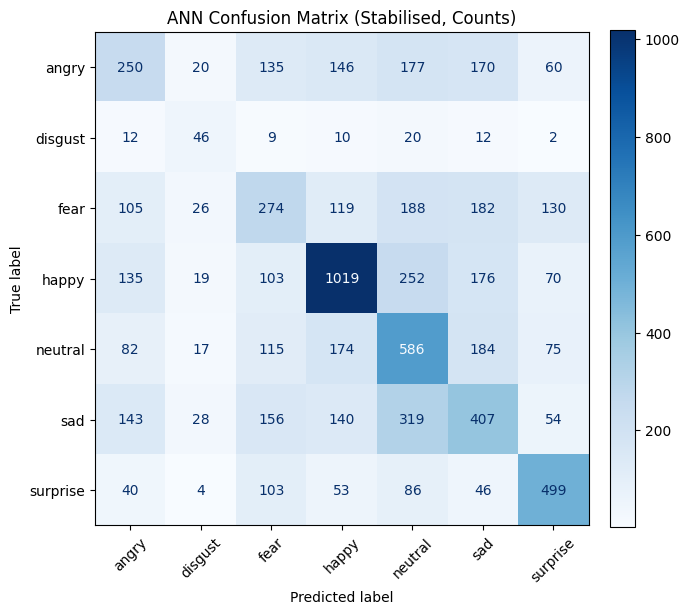

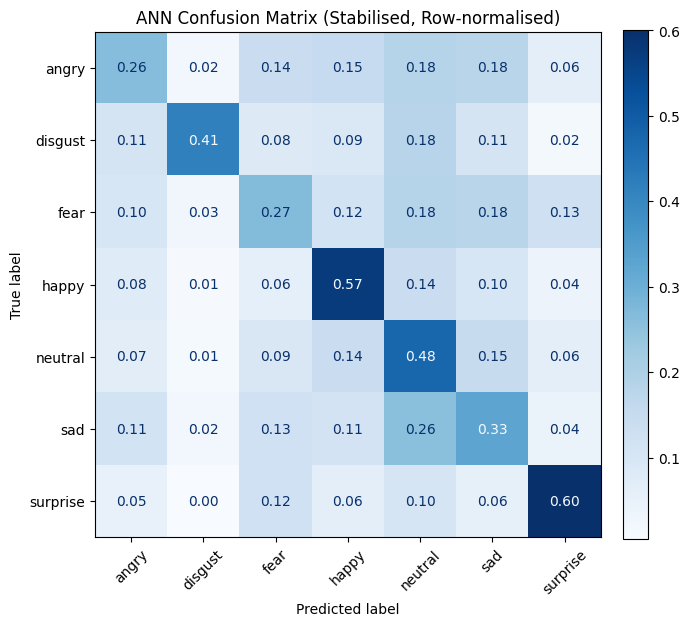


Saved confusion matrix PDFs to:
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\ann\ann_stabilised_cm_counts.pdf
 - C:\Users\16sim\OneDrive - Bath Spa University\GitHub Repositories\PC\artificial-intelligence-25-26\Assessments\Assessment-2-Machine-Learning\results\confusion-matrices\ann\ann_stabilised_cm_row_normalised.pdf


In [ ]:
# --- Evaluate ANN + Confusion Matrices (Counts + Row-normalised) + Save as PDFs ---
# This cell:
# 1) Evaluates on the held-out test set
# 2) Generates predictions + classification report
# 3) Plots confusion matrix (counts)
# 4) Plots confusion matrix (row-normalised)
# 5) Saves both confusion matrices as PDFs

import pathlib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1) Evaluate on held-out test set
# -----------------------------
# The test set is never used during training/validation.
test_loss, test_acc = ann.evaluate(X_test_f, y_test, verbose=0)
print(f"ANN Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 2) Predict labels (argmax over softmax probabilities)
# -----------------------------
y_pred = np.argmax(ann.predict(X_test_f, verbose=0), axis=1)

# -----------------------------
# 3) Classification report (precision/recall/F1)
# -----------------------------
print("\nClassification Report (ANN Stabilised):")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# -----------------------------
# 4) Prepare output folder and filenames
# -----------------------------
OUT_DIR = pathlib.Path("results/confusion-matrices/ann/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TITLE_PREFIX = "ANN"
FILE_PREFIX = "ann_stabilised"

# -----------------------------
# 5) Confusion Matrix (Counts)
# -----------------------------
cm_counts = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 7))

# Plot the matrix WITHOUT a colourbar (we'll add our own so it matches height)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_counts, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)

# Manually add a colourbar that is tied to the matrix axis (same height)
im = ax.images[0]  # the heatmap image
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Stabilised, Counts)")
fig.tight_layout()

counts_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_counts.pdf"
fig.savefig(counts_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)


# -----------------------------
# 6) Confusion Matrix (Row-normalised)
# -----------------------------
# Each row sums to 1.00, so you can compare per-class behaviour fairly.
cm_row = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(7, 7))

# Plot WITHOUT colourbar first
disp = ConfusionMatrixDisplay(confusion_matrix=cm_row, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)

# Add matching-height colourbar
im = ax.images[0]
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title(f"{TITLE_PREFIX} Confusion Matrix (Stabilised, Row-normalised)")
fig.tight_layout()

row_pdf_path = OUT_DIR / f"{FILE_PREFIX}_cm_row_normalised.pdf"
fig.savefig(row_pdf_path, format="pdf", bbox_inches="tight")
plt.show()
plt.close(fig)


# -----------------------------
# 7) Confirm saved files
# -----------------------------
print("\nSaved confusion matrix PDFs to:")
print(" -", counts_pdf_path.resolve())
print(" -", row_pdf_path.resolve())
